# Summarize the Results

In [1192]:
import os
import re
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import pandas as pandas
import matplotlib.pyplot as plt

from typing import Union

In [1193]:
BASE_PATH = "/data/local/kgutjahr/results/test/runs/eval/ADNI"

In [1194]:
BASE_DVM_PATH = "/data/local/kgutjahr/results/test/runs/eval/DVM"

In [1195]:
MET_DICT = {"multimodal.test.classifier.entropy": r"$f_{m}$ Entropy",
            "image.test.classifier.entropy": r"$f_{i}$ Entropy",
            "tabular.test.classifier.entropy": r"$f_{t}$ Entropy",
            "test.acc": "Accuracy",
            "test.balanced_acc": "Balanced Accuracy",
            "test.expert_no0.entropy": r"$f_{0}$ Entropy",
            "test.expert_no1.entropy": r"$f_{1}$ Entropy",
            "test.expert_no2.entropy": r"$f_{2}$ Entropy",
            "val.balanced_acc": "Balanced Accuracy (Validation)",
            "eval.val.acc": "Accuracy (Validation)",
            "MoE.test.weight0": r"Gate weight for $f_{m}$",
            "MoE.test.weight1": r"Gate weight for $f_{i}$",
            "MoE.test.weight2": r"Gate weight for $f_{t}$",
            "MoE.test.x_ai.class_prob_0": r"Ratio of $\mathit{z}_{s}^{i}$ being sent to $f_{1}$",
            "MoE.test.x_ai.class_prob_1": r"Ratio of $\mathit{z}_{s}^{i}$ being sent to $f_{2}$",
            "MoE.test.x_ai.class_prob_2": r"Ratio of $\mathit{z}_{s}^{i}$ being sent to $f_{3}$",
            "MoE.test.x_si_enhance.class_prob_0": r"Ratio of $\hat{\mathit{z}}_{i}^{t}$ being sent to $f_{1}$",
            "MoE.test.x_si_enhance.class_prob_1": r"Ratio of $\hat{\mathit{z}}_{i}^{t}$ being sent to $f_{2}$",
            "MoE.test.x_si_enhance.class_prob_2": r"Ratio of $\hat{\mathit{z}}_{i}^{t}$ being sent to $f_{3}$",
            "MoE.test.x_c.class_prob_0": r"Ratio of $\hat{\mathit{z}}_{t}$ being sent to $f_{1}$",
            "MoE.test.x_c.class_prob_1": r"Ratio of $\hat{\mathit{z}}_{t}$ being sent to $f_{2}$",
            "MoE.test.x_c.class_prob_2": r"Ratio of $\hat{\mathit{z}}_{t}$ being sent to $f_{3}$",
            "MoE.test.x_st_enhance.class_prob_0": r"Ratio of $\hat{\mathit{z}}_{c}^{t}$ being sent to $f_{1}$",
            "MoE.test.x_st_enhance.class_prob_1": r"Ratio of $\hat{\mathit{z}}_{c}^{t}$ being sent to $f_{2}$",
            "MoE.test.x_st_enhance.class_prob_2": r"Ratio of $\hat{\mathit{z}}_{c}^{t}$ being sent to $f_{3}$",
            "MoE.test.x_at.class_prob_0": r"Ratio of $\mathit{z}_{s}^{t}$ being sent to $f_{1}$",
            "MoE.test.x_at.class_prob_1": r"Ratio of $\mathit{z}_{s}^{t}$ being sent to $f_{2}$",
            "MoE.test.x_at.class_prob_2": r"Ratio of $\mathit{z}_{s}^{t}$ being sent to $f_{3}$",
            }

In [1196]:
def plot_grouped_heatmap(path: str):
    df = pd.read_csv(path).iloc[:, :-1]
    df = df.fillna(0)

    # Create combined Shift + Method column
    df['Shift_Method'] = df['Shift'] + " x " + df['Method']
    # Automatically select numeric columns
    
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index for heatmap
    heatmap_df = df.set_index('Shift_Method')[numeric_cols]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(heatmap_df, cmap="RdBu", annot=True, fmt=".1f", vmin=0, vmax=100)

    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Add thick horizontal lines between Shifts
    shift_groups = df.groupby('Shift').size().cumsum()  # positions where each shift ends
    for pos in shift_groups[:-1]:  # skip the last line
        ax.hlines(pos, *ax.get_xlim(), colors='black', linewidth=3)

    plt.title("Heatmap of Accuracy (in %)", pad=20)
    plt.ylabel("Shift x Method", labelpad=20)
    plt.xlabel("Modality", labelpad=10)
    plt.tight_layout()
    plt.show()

In [1197]:
def plot_heatmap(data):
    # Load CSV
    if isinstance(data, str):
        df = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df = data
    else:
        raise TypeError("Wrong type")

    # Fill missing values with 0
    df = df.fillna(0)

    # Automatically select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index with Shift + Method
    heatmap_df = df.set_index(["Shift"])[numeric_cols]

    # Plot heatmap with fixed color scale 0–100
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_df,
        cmap="RdBu",
        annot=True,
        fmt=".4f",
        vmin=0,
        vmax=np.log(286)
    )
    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.title("Entropy STiL DVM (in %)")
    plt.ylabel("Dataset Shift")
    plt.xlabel("CLassifier")
    plt.tight_layout()
    plt.show()

In [1198]:
def plot_one_grouped_df(df: pd.DataFrame, metrics: list[str], title: str, metric_name: str, markers=None, group_col=None):
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']

    x = df_copy[group_col] if group_col else df_copy.index
    
    group_name = group_col if group_col else x.name

    for i, metric in enumerate(metrics):
        # handle MultiIndex columns
        if isinstance(df_copy.columns, pd.MultiIndex):
            df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        
        mean = df_copy[f"{metric}.mean"]
        std = df_copy[f"{metric}.std"]

        if isinstance(x, pd.Index):
            x = x.to_numpy()
        
        #if isinstance(mean, pd.DataFrame) and isinstance(std, pd.DataFrame):
        #    df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        #    if isinstance(mean.columns, pd.MultiIndex):
        #        mean = mean[(metric, "mean")]
#
        #    if isinstance(std.columns, pd.MultiIndex):
        #        std = std[(metric, "std")]

        plt.plot(x, mean, label=metric, marker=markers[i % len(markers)], linewidth=2)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(group_name.capitalize())
    plt.ylabel(f"{metric_name} (mean ± std)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [1199]:
os.listdir("/home/stud/kgutjahr/STiL-TTA/STiL-MoE-Plots")

['STiL-MofE-k=1-MLP-bacc.png',
 'STiL-MofE-k=2-lin-acc.png',
 'STiL-MofE-k=2-MLP-bacc.png',
 'STiL-MofE-DVM-acc.png',
 'STiL-MofE-DVM-bacc.png',
 'STiL-MofE-k=3-MLP-bacc.png',
 'STiL-MofE-k=2-MLP-acc.png',
 'pdfs',
 'pdfs-new',
 'STiL-Switch-DVM-acc.png',
 'STiL-MofE-k=2-lin-bacc.png',
 'STiL-MofE-k=3-MLP-acc.png',
 'STiL-MofE-k=3-lin-bacc.png',
 'STiL-MofE-k=1-lin-bacc.png',
 'STiL-MofE-k=1-MLP-acc.png',
 'STiL-MofE-Swift-acc.png',
 'STiL-Switch-DVM-bacc.png',
 'STiL-MofE-k=3-lin-acc.png',
 'STiL-MofE-Swift-bacc.png',
 'STiL-MofE-k=1-lin-acc.png']

In [1200]:
from pandas.api.types import is_numeric_dtype

def plot_two_grouped_df(
    df: pd.DataFrame,
    first_group_col: str,
    second_group_col: str,
    metric: str,
    title: str,
    baseline_df: pd.DataFrame,
    xlabel: str = "x",
):
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))

    # --- MINIMAL CHANGE START ---
    # convert numeric x-values to strings so they are treated as categories
    df_copy[first_group_col] = df_copy[first_group_col].astype(str)
    # --- MINIMAL CHANGE END ---

    df = df.sort_values(by=first_group_col)

    # x-range for baselines
    x_min = df_copy[first_group_col].min()
    x_max = df_copy[first_group_col].max()

    color_map = {}

    # plot curves
    for name, subdf in df_copy.groupby(second_group_col):
        eps = subdf[first_group_col]
        mean = subdf[metric]["mean"]
        std = subdf[metric]["std"]

        line, = plt.plot(
            eps,
            mean,
            marker="o",
            linewidth=2,
            label=name,
            zorder=2,
        )
        color_map[name] = line.get_color()

        plt.fill_between(
            eps,
            mean - std,
            mean + std,
            color=color_map[name],
            alpha=0.1,
            zorder=1,
            edgecolor=color_map[name],
            linewidth=1.5,
        )

    # plot baselines
    subset_map = {
        "normal": "No-Shift",
        "TE": "TE",
        "age": "Age",
        "weight": "Weight",
        "black": "Black",
        "color": "Color-Miles",
        "miles": "Miles",
        "color_miles": "Color-Miles"
    }

    if baseline_df is not None:
        for shift, row in baseline_df.iterrows():
            base_mean = row[metric]["mean"]
            color = color_map.get(subset_map.get(str(shift), ""), "k")

            plt.hlines(
                y=base_mean,
                xmin=x_min,
                xmax=x_max,
                linestyle="--",
                linewidth=2,
                color=color,
                alpha=1.0,
                label=f"{subset_map.get(str(shift), str(shift))} Baseline",
                zorder=3,
            )

    # ---- legend: pair curve + baseline on same row ----
    ax = plt.gca()
    # --- MINIMAL CHANGE: set categorical x-ticks ---
    categories = df_copy[first_group_col].unique()
    ax.set_xticks(categories)
    ax.set_xticklabels(categories)

    ymin, ymax = ax.get_ylim()
    padding = 0.2 * (ymax - ymin)
    ax.set_ylim(ymin - padding, ymax)

    handles, labels = ax.get_legend_handles_labels()

    paired_handles = []
    paired_labels = []
    used = set()

    for i, label in enumerate(labels):
        if label.endswith("Baseline"):
            continue

        baseline_label = f"{label} Baseline"
        if baseline_label in labels:
            j = labels.index(baseline_label)
            paired_handles.extend([handles[i], handles[j]])
            paired_labels.extend([labels[i], labels[j]])
            used.update([i, j])

    # include any leftover entries
    for i, (h, l) in enumerate(zip(handles, labels)):
        if i not in used:
            paired_handles.append(h)
            paired_labels.append(l)

    plt.legend(
        paired_handles,
        paired_labels,
        title="Distribution Shift",
        loc="lower left",
        framealpha=0.6,
        ncol=2,
        title_fontsize=14,
        fontsize=12
    )

    plt.title(title, fontsize=18)
    plt.xlabel(xlabel, fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylabel(f"{MET_DICT[metric]} (mean ± std)", fontsize=16)
    plt.grid(True, linestyle="--")
    plt.savefig(os.path.join("/home/stud/kgutjahr/STiL-TTA/STiL-MoE-Plots/pdfs-new", title.replace(" ", "_"))+".pdf")

In [1201]:
def create_one_group_df(dir_path: str, filename: str, batchsize: bool = False, one_per_seed: bool = False) -> pd.DataFrame:
    df = pd.DataFrame()
    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
            
        for file in os.listdir(subdir_path):
            file_path = os.path.join(dir_path, subdir, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue
            file_df = pd.read_csv(file_path)
            shift = ""
            batch = ""
            seed = ""
            if batchsize:
                #print(subdir)
                pattern = r'adni_(.*?)_final(?:\.yaml)?_(\d+)(?:_seed_(\d+))?'
                m = re.search(pattern, subdir)
                if m:
                    #print(m.group(1))
                    file_df["Shift"] = m.group(1)
                    shift = m.group(1)
                    file_df["BatchSize"] = m.group(2)
                    batch = m.group(2)
                    if m.group(3):
                        file_df["Seed"] = m.group(3)
                        seed = m.group(3)
                    else:
                        file_df["Seed"] = "2022"
                        seed = "2022"
            else:
                #print(dir_path)
                pattern = r'(?:^|_)([a-zA-Z0-9]+)(?=_final)(?:_final_seed_(\d+))?' if "DVM" not in dir_path else r"TIP_([a-zA-Z0-9_]+?)(?=_(?:seed_(\d+)|dvm))"
                #print(pattern)
                m = re.search(pattern, subdir)
                if m:
                    file_df["Shift"] = m.group(1)
                    shift = m.group(1)
                    if m.group(2):
                        file_df["Seed"] = m.group(2)
                        seed = m.group(2)
                    else:
                        file_df["Seed"] = "2022"
                        seed = "2022"
                else:
                    file_df["Shift"] = subdir.split("_")[0]
            
            if df.empty:
                df = file_df
            else:
                if one_per_seed:
                    if batchsize:
                        df = pd.concat([df, file_df], axis=0) if ~((df["Shift"] == shift) & (df["BatchSize"] == batch) & (df["Seed"] == seed)).any() else df
                    else:
                        df = pd.concat([df, file_df], axis=0) if ~((df["Shift"] == shift) & (df["Seed"] == seed)).any() else df
                else:
                    df = pd.concat([df, file_df], axis=0)
    return df.reset_index(drop=True)

In [1202]:
def create_two_group_df(dir_path: str, filename: str, group_col: str, exp_name: str, pattern=r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed") -> pd.DataFrame:
    df = pd.DataFrame()
    # Escape curly braces that belong to the regex (not the format string)
    pattern = pattern.format(exp_name=re.escape(exp_name))
    pattern = re.compile(pattern)

    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue

        match = pattern.search(subdir)
        consent_num, consent_label = (None, None)
        
        if match:
            consent_num = match.group(1)
            consent_label = match.group(2)

        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue

            #print(file_path)
            file_df = pd.read_csv(file_path)
            file_df[group_col] = consent_num
            file_df["Shift"] = consent_label

            df = pd.concat([df, file_df], axis=0, ignore_index=True)

    return df

In [1203]:
def create_three_group_df(dir_path: str, filename: str, one_per_seed: bool = False) -> pd.DataFrame:
    df = pd.DataFrame()
    
    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
        
        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue
            
            #print(file_path)
            file_df = pd.read_csv(file_path)
            
            # Default values
            shift = ""
            seed = ""
            method = ""
            classifier = ""
            
            # Extract Shift (from TIP or _final) and optional Seed
            if "DVM" not in dir_path:
                pattern = r'(?:^|_)latent_([a-zA-Z0-9]+)_([a-zA-Z0-9]+)_(?:.*_)?([a-zA-Z0-9]+)(?:_final_seed_(\d+))'
            else:
                pattern = r'TIP_([a-zA-Z0-9_]+?)(?=_(?:seed_(\d+)|dvm))'
            m = re.search(pattern, subdir)
            if m:
                classifier = m.group(1)
                method = m.group(2)
                shift = m.group(3)
                seed = m.group(4) if len(m.groups()) > 1 and m.group(2) else "2022"
                file_df["Shift"] = shift
                file_df["Classifier"] = classifier
                file_df["Seed"] = seed
                file_df["Method"] = method
            else:
                shift = subdir.split("_")[0]
                file_df["Shift"] = shift
            
            # Append file_df to main df
            if df.empty:
                df = file_df
            else:
                if one_per_seed:
                    df = pd.concat([df, file_df], axis=0) if ~((df["Shift"] == shift) & (df["Seed"] == seed)).any() else df
                else:
                    df = pd.concat([df, file_df], axis=0)
    
    return df.reset_index(drop=True)


In [1204]:
def make_df_numeric(df: pd.DataFrame):
    def parse_tensor_string(x):
        if isinstance(x, str) and x.startswith("tensor"):
            match = re.search(r"tensor\(\s*([-+]?\d*\.?\d+)", x)
            if match:
                return float(match.group(1))
            else:
                return x
        return x
    
    return df.applymap(parse_tensor_string)

In [1205]:
def summarize_df(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    for col in df.columns:
        if col == group_col:
            continue
        if df[col].apply(torch.is_tensor).all():
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])

In [1206]:
def summarize_two_groups_df(df: pd.DataFrame, first_group_col: str, second_group_col: str) -> pd.DataFrame:
    df = make_df_numeric(df)
    
    numeric_cols = df.select_dtypes(include=["number"]).columns

    # group by epsilon and name, then compute mean and std for numeric columns
    grouped = df.groupby([first_group_col, second_group_col])[numeric_cols].agg(
        [('mean', lambda x: x.mean(skipna=True)), 
         ('std', lambda x: x.std(skipna=True))]
    ).reset_index()
    
    return grouped

In [1207]:
def plot_bar_df(df, metric='test.acc', x_label='Category', y_label='Value', title='Bar Plot', figsize=(8,6), colors=None):
    """
    Plots a bar chart for a MultiIndex column DataFrame (metric, stat).
    
    Parameters:
        df (pd.DataFrame): MultiIndex columns DataFrame with (metric, stat), e.g., ('test.acc','mean'), ('test.acc','std')
        metric (str): Which metric to plot.
        x_label, y_label, title, figsize, colors: plot customization
    """
    if not isinstance(df.columns, pd.MultiIndex):
        raise ValueError("DataFrame must have MultiIndex columns (metric, stat)")
    
    categories = df.index
    mean_col = (metric, 'mean')
    std_col = (metric, 'std') if (metric, 'std') in df.columns else None
    
    means = df[mean_col]
    stds = df[std_col] if std_col is not None else None
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(categories, means, yerr=stds, capsize=5, color=colors)
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Final Dataset

In [1208]:
import re

def format_latex_table(raw: str) -> str:
    lines = raw.strip().splitlines()

    data_rows = []
    for line in lines:
        line = line.strip()

        # Match data rows like: 32 & 0.8409 $\pm$ 0.0015 & ...
        match = re.match(
            r"(\d+)\s*&\s*([\d.]+)\s*\\pm\s*([\d.]+)\s*&\s*([\d.]+)\s*\\pm\s*([\d.]+)",
            line
        )
        if match:
            bs, acc, acc_std, bal, bal_std = match.groups()

            row = (
                f"{bs} & "
                f"{float(acc):.4f} $\\pm$ {float(acc_std):.3f} & "
                f"{float(bal):.4f} $\\pm$ {float(bal_std):.3f} \\\\"
            )
            data_rows.append(row)

    table = [
        r"\begin{table}",
        r"\centering",
        r"\begin{tabular}{lll}",
        r"\hline",
        r"Batch Size & Accuracy & Balanced Accuracy \\",
        r"\hline",
        *data_rows,
        r"\hline",
        r"\end{tabular}",
        r"\end{table}",
    ]

    return "\n".join(table)

In [1209]:
def convert_to_latex(df: pd.DataFrame):
    df_fmt = df.copy()
    df_fmt[("test.acc", "mean")] = (
        df[("test.acc", "mean")].map("{:.4f}".format)
        + " $\\pm$ "
        + df[("test.acc", "std")].map("{:.4f}".format)
    )
    
    df_fmt[("test.balanced_acc", "mean")] = (
        df[("test.balanced_acc", "mean")].map("{:.4f}".format)
        + " $\\pm$ "
        + df[("test.balanced_acc", "std")].map("{:.4f}".format)
    )
    
    df_final = df_fmt.drop(columns=[
        ("test.acc", "std"),
        ("test.balanced_acc", "std")
    ])
    
    print(df_final.to_latex(escape=False))

### Batchsize

In [1210]:
f_batch_path = os.path.join(BASE_PATH, "final_dataset/baseline")
group_col = "epsilon"
df_c_f_batch = create_one_group_df(dir_path=f_batch_path, filename="test", batchsize=True, one_per_seed=True)
#display(df_c_f_batch)
df_c_f_batch["BatchSize"] = pd.to_numeric(df_c_f_batch["BatchSize"], errors='coerce')
summed_f_batch_df = summarize_df(df=df_c_f_batch, group_col="BatchSize")
summed_f_batch_df[["test.acc", "test.balanced_acc"]]

/tmp/ipykernel_2214383/1263068295.py:7: FutureWarning: ['Shift'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])


test.acc           test.balanced_acc          
               mean       std              mean       std
BatchSize                                                
32         0.840889  0.001540          0.757470  0.012946
64         0.841778  0.005551          0.752569  0.012038
128        0.842667  0.002667          0.751483  0.006917
256        0.845333  0.003771          0.756859  0.009402

In [1211]:
f_batch_path = os.path.join(BASE_PATH, "final_dataset/baseline")
group_col = "epsilon"
df_c_f_batch_val = create_one_group_df(dir_path=f_batch_path, filename="eval", batchsize=True, one_per_seed=True)
#display(df_c_f_batch)
df_c_f_batch_val["BatchSize"] = pd.to_numeric(df_c_f_batch_val["BatchSize"], errors='coerce')
summed_f_batch_df_val = summarize_df(df=df_c_f_batch_val, group_col="BatchSize")
summed_f_batch_df_val[["eval.val.acc", "eval.val.balanced_acc"]]

/tmp/ipykernel_2214383/1263068295.py:7: FutureWarning: ['Shift'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])


eval.val.acc           eval.val.balanced_acc          
                  mean       std                  mean       std
BatchSize                                                       
32            0.831133  0.010108                0.7939  0.017112
64            0.827533  0.005564                0.7745  0.021496
128           0.836433  0.008140                0.7855  0.009334
256           0.822650  0.001909                0.7641       NaN

### Baseline

In [1212]:
f_base_path = os.path.join(BASE_PATH, "final_dataset/batchsize")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="test", one_per_seed=True)
display(df_c_f_base["Shift"].value_counts())
summed_f_base_df_adni = summarize_df(df=df_c_f_base, group_col="Shift")
summed_f_base_df_adni[["test.acc", "test.balanced_acc"]]

age       3
weight    3
TE        3
normal    3
Name: Shift, dtype: int64

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [1213]:
def plot_results(path: str, group_col: str, filename: str, second_group_col: str, exp_name: str, metric: Union[str, list[str]], title: str, moe:bool = True, pattern: str = r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed", base_path:str=BASE_PATH, just_plot=True):
    subset_map = {"normal": "No-Shift", "TE": "TE", "age": "Age", "weight": "Weight", "black": "Black", "color": "Color-Miles", "miles": "Miles", "color-miles": "Color-Miles"}
    moe_path = os.path.join(base_path, path)
    df_c_moe = create_two_group_df(dir_path=moe_path, filename=filename, group_col=group_col, exp_name=exp_name, pattern=pattern)
    summed_c_moe_df = summarize_two_groups_df(df=df_c_moe, first_group_col=group_col, second_group_col=second_group_col)
    #display(summed_c_moe_df)
    summed_c_moe_df["Shift"] = summed_c_moe_df["Shift"].replace(subset_map)
    summed_c_moe_df = summed_c_moe_df[summed_c_moe_df["epsilon"] != "4"]
    moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight') or str(c[0]) in [group_col, second_group_col]]
    
    if moe_cols and moe:
        moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight')]
        moe_mean_cols = summed_c_moe_df[moe_cols].xs('mean', axis=1, level=1)

        # Prepare a DataFrame to collect max rows
        max_rows = pd.DataFrame()
        extra_cols = [('Shift', ''), ('epsilon', '')]

        # Iterate over shifts
        for shift, group_df in summed_c_moe_df.groupby(('Shift', '')):
            #if not just_plot:
                #print(f"\nShift: {shift}")
            for col in moe_mean_cols.columns:
                max_val = group_df[col]['mean'].max()  # max value for this weight in this shift
                rows = group_df[group_df[col]['mean'] == max_val]  # rows reaching the max
                #if not just_plot:
                #    print(f"{col} max value: {max_val}")
                #display(rows)
                # Optionally collect all rows
                max_rows = pd.concat([max_rows, rows])
        #if not just_plot:
        #    display(max_rows[extra_cols + moe_cols])
        #display(summed_c_moe_df[extra_cols + moe_cols])

    metric_list = metric if isinstance(metric, list) else  [metric]
    for met in metric_list:
        met_name = MET_DICT[met]
        t = title + f" {met_name}"
        xlabel = "ξ" if "STiL-Switch" in title else "ε"
        baseline_df = pd.DataFrame()
        if "DVM" in base_path:
            baseline_df = summed_f_base_df[[met]]
        else:
            baseline_df = summed_f_base_df_adni[[met]]
        plot_two_grouped_df(df=summed_c_moe_df, first_group_col=group_col, second_group_col=second_group_col, metric=met, title=t, xlabel=xlabel, baseline_df=baseline_df)
    
    if isinstance(metric, list):
        cols = [group_col, second_group_col] + metric
    else:
        cols = [group_col, second_group_col]
        
    if filename == "test":
        cols += ["test.acc", "test.balanced_acc"]
    if filename == "eval":
        cols += ["eval.val.acc", "val.balanced_acc"]       
        
    #display(summed_c_moe_df[list(set(cols))])
    
    moe_cols = ["test.balanced_acc"] if filename == "test" else ["val.balanced_acc"]
    moe_mean_cols = summed_c_moe_df[moe_cols].xs('mean', axis=1, level=1)
    # Prepare a DataFrame to collect max rows
    max_rows = pd.DataFrame()
    extra_cols = [('Shift', ''), ('epsilon', '')]
    # Iterate over shifts
    for shift, group_df in summed_c_moe_df.groupby(('Shift', '')):
        for col in moe_mean_cols.columns:
            max_val = group_df[col]['mean'].max()  # max value for this weight in this shift
            rows = group_df[group_df[col]['mean'] == max_val]  # rows reaching the max
            #display(rows)
            # Optionally collect all rows
            max_rows = pd.concat([max_rows, rows])
    #if filename == "test":
    #    metric_cols = [('test.acc', 'mean'), ('test.acc', 'std'), ('test.balanced_acc', 'mean'), ('test.balanced_acc', 'std'), ("MoE.test.weight0", 'mean'), ("MoE.test.weight0", 'std'), ("MoE.test.weight1", 'mean'), ("MoE.test.weight1", 'std'), ("MoE.test.weight2", 'mean'), ("MoE.test.weight2", 'std')]
    #else:
    #    metric_cols = [('eval.val.acc', 'mean'), ('eval.val.acc', 'std'), ("val.balanced_acc", 'mean'), ("val.balanced_acc", 'std')]
    #display(max_rows[extra_cols + metric_cols])
    #if "DVM" in base_path:
    #    display(summed_f_base_df[["test.acc", "test.balanced_acc"]])
    #else:
    #    display(summed_f_base_df_adni[["test.acc", "test.balanced_acc"]])
    #    
    ##display(summed_c_moe_df.columns)
    #try:
    #    display(summed_c_moe_df[extra_cols + [("multimodal.test.balanced_acc", "mean"), ("multimodal.test.balanced_acc", "std"), ("test.acc_multimodal", "mean"), ("test.acc_multimodal", "std")]])
    #except:
    #    print("No Multimodal classifier available.")
    #    #display(summed_c_moe_df[extra_cols + [("test.expert_no0.balanced_acc", "mean"), ("test.expert_no0.balanced_acc", "std"), ("test.acc_multimodal", "mean"), ("test.acc_multimodal", "std")]])

In [1214]:
metric = ["test.balanced_acc"]

In [1215]:
f_base_path = os.path.join(BASE_PATH, "final_dataset/batchsize")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="eval", one_per_seed=True)
summed_f_base_df_adni_train = summarize_df(df=df_c_f_base, group_col="Shift")

In [1216]:
summed_f_base_df_adni[["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"]]  

multimodal.test.classifier.entropy            \
                                     mean       std   
Shift                                                 
TE                               0.451688  0.005861   
age                              0.548849  0.029364   
normal                           0.458434  0.073259   
weight                           0.502436  0.045353   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
TE                          1.016213  0.034405   
age                         0.977101  0.004334   
normal                      1.030628  0.038214   
weight                      1.000474  0.020076   

       tabular.test.classifier.entropy            
                                  mean       std  
Shift                                             
TE                            0.488810  0.023102  
age                           0.583696  0.033005  
normal                        0.497962  0.062017  
weight                        0.548109  0.068495

In [1217]:
summed_f_base_df_adni_train[["multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy"]]  

multimodal.classifier.entropy           image.classifier.entropy  \
                                mean       std                     mean   
Shift                                                                     
TE                          0.523133  0.008001                 0.991867   
age                         0.502767  0.017451                 1.005200   
normal                      0.502433  0.009073                 0.995700   
weight                      0.510867  0.009226                 1.000167   

                 tabular.classifier.entropy            
             std                       mean       std  
Shift                                                  
TE      0.004765                   0.531033  0.013042  
age     0.008184                   0.509500  0.008550  
normal  0.005429                   0.505633  0.012832  
weight  0.005541                   0.514500  0.005977

In [1218]:
#plot_one_grouped_df(summed_f_base_df_adni, metrics=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Classifier Case Ratio", metric_name="Case Ratio")

In [1219]:
summed_f_base_df_adni[["multimodal.test.balanced_acc", "image.test.balanced_acc", "tabular.test.balanced_acc", "test.acc_multimodal", "test.acc_imaging", "test.acc_tabular"]]  

multimodal.test.balanced_acc           image.test.balanced_acc          \
                               mean       std                    mean     std   
Shift                                                                           
TE                         0.819313  0.012563                0.555556  0.3849   
age                        0.818361  0.009531                0.555556  0.3849   
normal                     0.752783  0.004264                0.555556  0.3849   
weight                     0.841267  0.022204                0.555556  0.3849   

       tabular.test.balanced_acc           test.acc_multimodal            \
                            mean       std                mean       std   
Shift                                                                      
TE                      0.828629  0.008621            0.852444  0.009365   
age                     0.805717  0.008937            0.818667  0.016000   
normal                  0.772443  0.004354            0.840000  0.002667   
weight                  0.846619  0.002340            0.854222  0.007698   

       test.acc_imaging      test.acc_tabular            
                   mean  std             mean       std  
Shift                                                    
TE             0.506667  0.0         0.849778  0.008572  
age            0.661333  0.0         0.816889  0.015163  
normal         0.493333  0.0         0.845333  0.009238  
weight         0.477333  0.0         0.852444  0.003079

In [1220]:
summed_f_base_df_adni_train[["multimodal.train.balanced_acc", "image.train.balanced_acc", "tabular.train.balanced_acc", "classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc"]]

multimodal.train.balanced_acc           image.train.balanced_acc  \
                                mean       std                     mean   
Shift                                                                     
TE                          0.716200  0.015744                 0.556767   
age                         0.729467  0.011451                 0.433367   
normal                      0.750033  0.008975                 0.446700   
weight                      0.721500  0.012875                 0.456867   

                 tabular.train.balanced_acc           classifier.multi.acc  \
             std                       mean       std                 mean   
Shift                                                                        
TE      0.383856                   0.715200  0.019649             0.776967   
age     0.169706                   0.728633  0.003485             0.789500   
normal  0.196761                   0.747367  0.002901             0.793133   
weight  0.214024                   0.720433  0.009266             0.781033   

                 classifier.image.acc           classifier.tab.acc            
             std                 mean       std               mean       std  
Shift                                                                         
TE      0.006201             0.543200  0.000000           0.777167  0.007510  
age     0.004551             0.492267  0.009252           0.787900  0.006935  
normal  0.008975             0.528067  0.002994           0.791567  0.006101  
weight  0.013795             0.515967  0.000751           0.782167  0.006951

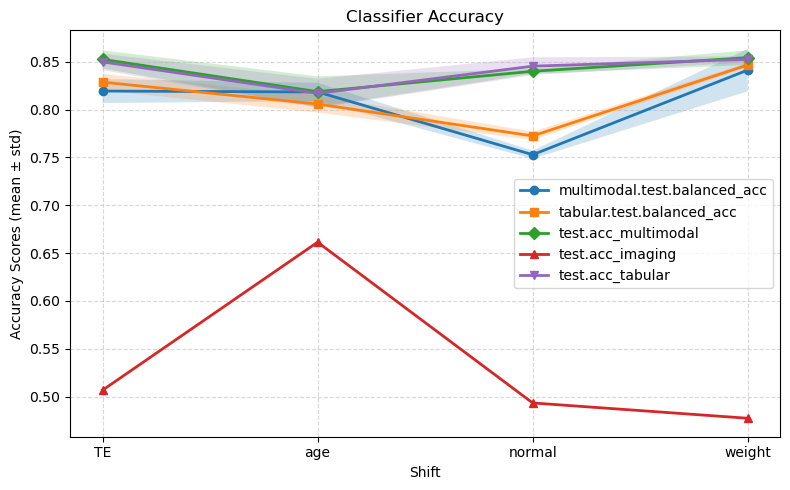

In [1221]:
plot_one_grouped_df(summed_f_base_df_adni, metrics=["multimodal.test.balanced_acc", "tabular.test.balanced_acc", "test.acc_multimodal", "test.acc_imaging", "test.acc_tabular"], title="Classifier Accuracy", metric_name="Accuracy Scores")

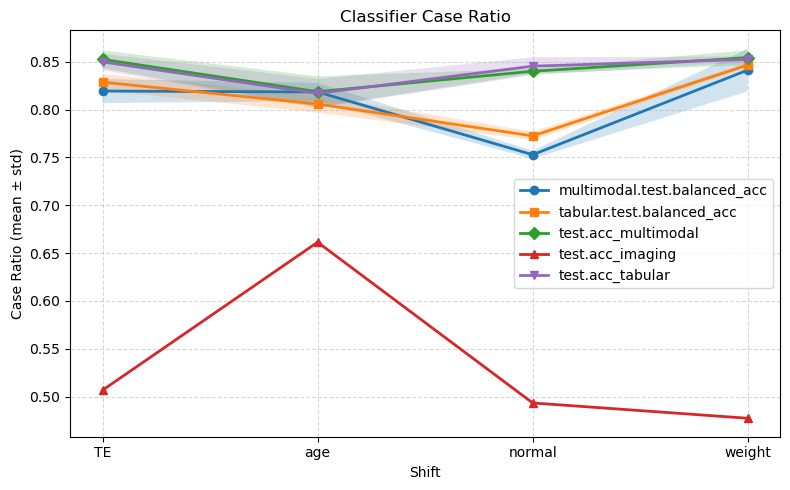

In [1222]:
plot_one_grouped_df(summed_f_base_df_adni, metrics=["multimodal.test.balanced_acc", "tabular.test.balanced_acc", "test.acc_multimodal", "test.acc_imaging", "test.acc_tabular"], title="Classifier Case Ratio", metric_name="Case Ratio")

In [1223]:
def create_loss_df(dir_path: str, filename: str, group_col: str, exp_name: str, metric: str, pattern=r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed") -> pd.DataFrame:
    df = pd.DataFrame()
    # Escape curly braces that belong to the regex (not the format string)
    pattern = pattern.format(exp_name=re.escape(exp_name))
    pattern = re.compile(pattern)

    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
        subdir_files = os.listdir(subdir_path)
        if not {"train_loss_metrics.csv", "val_loss_metrics.csv"}.issubset(subdir_files):
            continue

        # extract number and word after "consent_"
        match = pattern.search(subdir)
        consent_num, consent_label = (None, None)
        if match:
            consent_num = match.group(1)
            consent_label = match.group(2)

        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue

            #print(file_path)
            file_df = pd.read_csv(file_path)[[metric]].copy()
            
            # Add epsilon (group_col) and shift
            file_df[group_col] = consent_num
            file_df["Shift"] = consent_label

            # Create MultiIndex: top = shift, middle = epsilon, bottom = metric
            multi_cols = pd.MultiIndex.from_tuples([(consent_label, consent_num, metric)])

            multi_file_df = pd.DataFrame(file_df[metric].values, columns=multi_cols)

            # Concatenate horizontally into master df
            if df.empty:
                df = multi_file_df
            else:
                df = pd.concat([df, multi_file_df], axis=1)

    return df

In [1224]:
import matplotlib.cm as cm

def plot_loss_curves(path: str, group_col: str, exp_name: str, metric: str, plot_split : str, epsilon=None, shift=None, pattern: str = r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed", base_path:str=BASE_PATH):
    moe_path = os.path.join(base_path, path)
    df_c_moe_train = create_loss_df(dir_path=moe_path, filename="train_loss_metrics", group_col=group_col, exp_name=exp_name, pattern=pattern, metric=metric)
    df_c_moe_val = create_loss_df(dir_path=moe_path, filename="val_loss_metrics", group_col=group_col, exp_name=exp_name, pattern=pattern, metric=metric.replace("train", "val"))
    df_agg_train = df_c_moe_train.groupby(level=[0, 1], axis=1).mean()
    df_agg_val = df_c_moe_val.groupby(level=[0, 1], axis=1).mean()
    if epsilon:
        df_agg_train = df_agg_train.xs(key=str(epsilon), level=1, axis=1)
        df_agg_val = df_agg_val.xs(key=str(epsilon), level=1, axis=1)
    if shift:
        df_agg_train = df_agg_train.xs(key=str(shift), level=0, axis=1)
        df_agg_val = df_agg_val.xs(key=str(shift), level=0, axis=1)
    
    display(df_agg_train)
    display(df_agg_val)

    df_plot_train = df_agg_train.copy()
    if isinstance(df_plot_train.columns, pd.MultiIndex):
        df_plot_train.columns = ['_'.join(map(str, col)) for col in df_plot_train.columns]
    else:
        df_plot_train.columns = df_plot_train.columns
    
    df_plot_val = df_agg_val.copy()
    if isinstance(df_plot_val.columns, pd.MultiIndex):
        df_plot_val.columns = ['_'.join(map(str, col)) for col in df_plot_val.columns]
    else:
        df_plot_val.columns = df_plot_val.columns    
    
    # Create color maps for unique colors
    cmap_train = cm.get_cmap('tab20', len(df_plot_train.columns))
    cmap_val = cm.get_cmap('tab20', len(df_plot_val.columns))

    plt.figure(figsize=(12, 6))

    # Plot train curves
    if plot_split == "train" or plot_split == "all":
        for i, col in enumerate(df_plot_train.columns):
            plt.plot(df_plot_train.index, df_plot_train[col], color=cmap_train(i), linestyle='-', label=f"Train: {col}")

    # Plot val curves
    if plot_split == "val" or plot_split == "all":
        for i, col in enumerate(df_plot_val.columns):
            plt.plot(df_plot_val.index, df_plot_val[col], color=cmap_val(i), linestyle='--', label=f"Val: {col}")

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title("Loss curves by shift/metric")
    plt.legend(ncol=2, fontsize=10)  # optional: make legend smaller or multi-column
    plt.show()

TE                                                    age  \
           0.1        0.5          1          2          3        0.1   
0    51.514825  51.961987  52.520671  53.638337  54.756021  51.424076   
1    19.731916  20.146363  20.662446  21.697927  22.732772  19.716316   
2    11.901890  12.288247  12.763099  13.692641  14.602485  11.907941   
3    11.327642  11.634458  12.006186  12.735756  13.449829  11.328592   
4    11.129213  11.409234  11.756472  12.442086  13.124750  11.131567   
..         ...        ...        ...        ...        ...        ...   
162        NaN        NaN        NaN        NaN        NaN        NaN   
163        NaN        NaN        NaN        NaN        NaN        NaN   
164        NaN        NaN        NaN        NaN        NaN        NaN   
165        NaN        NaN        NaN        NaN        NaN        NaN   
166        NaN        NaN        NaN        NaN        NaN        NaN   

                                                    normal             \
           0.5          1          2          3        0.1        0.5   
0    51.868823  52.424826  53.536625  54.648430  51.609572  52.057836   
1    20.135410  20.661089  21.710433  22.759652  19.741044  20.157693   
2    12.291206  12.762612  13.686481  14.589501  11.905509  12.291010   
3    11.636136  12.008951  12.740491  13.458230  11.324980  11.632505   
4    11.407317  11.749720  12.427357  13.104938  11.131040  11.412101   
..         ...        ...        ...        ...        ...        ...   
162        NaN        NaN        NaN        NaN        NaN        NaN   
163        NaN        NaN        NaN        NaN        NaN        NaN   
164        NaN        NaN        NaN        NaN        NaN        NaN   
165        NaN        NaN        NaN        NaN        NaN        NaN   
166        NaN        NaN        NaN        NaN        NaN        NaN   

                                         weight                        \
             1          2          3        0.1        0.5          1   
0    52.617778  53.738373  54.858430  51.467468  51.925728  52.498623   
1    20.678837  21.717487  22.757198  19.720764  20.143513  20.671853   
2    12.769130  13.698401  14.616534  11.906114  12.291419  12.766745   
3    12.006656  12.741930  13.461222  11.319194  11.619891  11.988369   
4    11.753820  12.436888  13.109466  11.128861  11.409538  11.758774   
..         ...        ...        ...        ...        ...        ...   
162        NaN  11.693529        NaN        NaN        NaN        NaN   
163        NaN  11.666202        NaN        NaN        NaN        NaN   
164        NaN  11.739920        NaN        NaN        NaN        NaN   
165        NaN  11.702178        NaN        NaN        NaN        NaN   
166        NaN  11.658773        NaN        NaN        NaN        NaN   

                           
             2          3  
0    53.644162  54.789716  
1    21.727666  22.784715  
2    13.689655  14.596676  
3    12.700040  13.393720  
4    12.447691  13.127269  
..         ...        ...  
162        NaN        NaN  
163        NaN        NaN  
164        NaN        NaN  
165        NaN        NaN  
166        NaN        NaN  

[167 rows x 20 columns]

TE                                                         age  \
            0.1         0.5           1           2           3         0.1   
0    306.103628  306.578857  307.116750  308.215357  309.349528  298.123322   
1     38.317303   38.765165   39.325392   40.445424   41.565633   38.187697   
2     12.352158   12.766478   13.269994   14.284369   15.292633   12.358692   
3     11.391513   11.713266   12.100482   12.811420   13.473039   11.354037   
4     11.087648   11.326959   11.621676   12.195882   12.765293   11.032200   
..          ...         ...         ...         ...         ...         ...   
163         NaN         NaN         NaN         NaN         NaN         NaN   
164         NaN         NaN         NaN         NaN         NaN         NaN   
165         NaN         NaN         NaN         NaN         NaN         NaN   
166         NaN         NaN         NaN         NaN         NaN         NaN   
167         NaN         NaN         NaN         NaN         NaN         NaN   

                                                         normal              \
            0.5           1           2           3         0.1         0.5   
0    298.565608  299.119873  300.250178  301.352249  274.217163  274.655162   
1     38.630885   39.184886   40.292688   41.400717   38.252875   38.700798   
2     12.754482   13.260258   14.262186   15.256010   12.339751   12.741208   
3     11.639780   11.980975   12.602392   13.179946   11.358672   11.662647   
4     11.234838   11.477638   11.944688   12.402820   11.048299   11.266638   
..          ...         ...         ...         ...         ...         ...   
163         NaN         NaN         NaN         NaN         NaN         NaN   
164         NaN         NaN         NaN         NaN         NaN         NaN   
165         NaN         NaN         NaN         NaN         NaN         NaN   
166         NaN         NaN         NaN         NaN         NaN         NaN   
167         NaN         NaN         NaN         NaN         NaN         NaN   

                                             weight                          \
              1           2           3         0.1         0.5           1   
0    275.215276  276.323822  277.423004  288.200022  288.647949  289.237717   
1     39.261056   40.381379   41.501592   38.074521   38.530425   39.099955   
2     13.238488   14.228535   15.209393   12.355580   12.752132   13.245536   
3     12.027294   12.699427   13.313886   11.357191   11.667850   12.034417   
4     11.540872   12.071326   12.593344   11.061354   11.276621   11.545606   
..          ...         ...         ...         ...         ...         ...   
163         NaN   11.664819         NaN         NaN         NaN         NaN   
164         NaN   11.580592         NaN         NaN         NaN         NaN   
165         NaN   11.701693         NaN         NaN         NaN         NaN   
166         NaN   11.642606         NaN         NaN         NaN         NaN   
167         NaN   11.565578         NaN         NaN         NaN         NaN   

                             
              2           3  
0    290.390106  291.543645  
1     40.239120   41.378218  
2     14.227424   15.204314  
3     12.712207   13.349881  
4     12.066710   12.584493  
..          ...         ...  
163         NaN         NaN  
164         NaN         NaN  
165         NaN         NaN  
166         NaN         NaN  
167         NaN         NaN  

[168 rows x 20 columns]

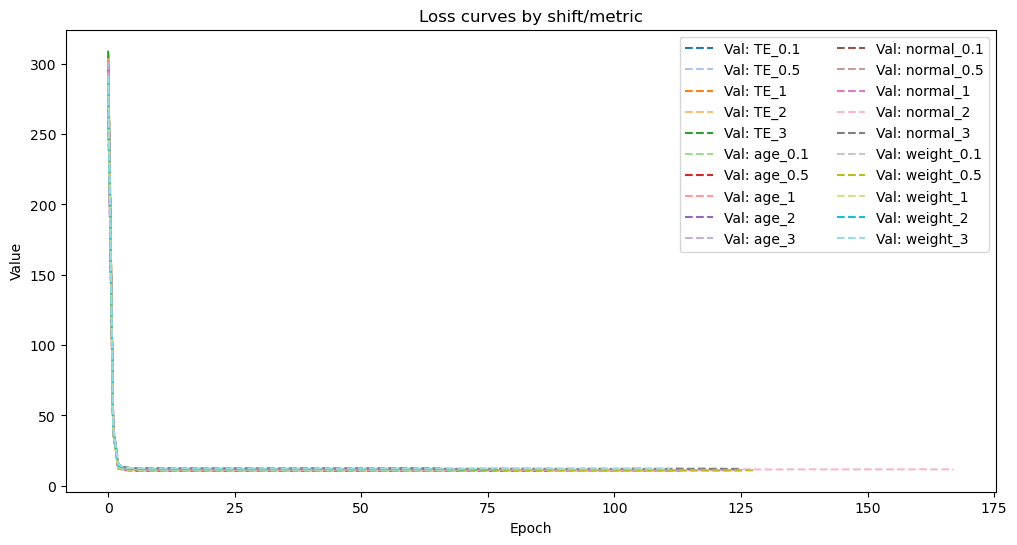

In [1225]:
plot_loss_curves(path="final_dataset/MoE3-MLP", group_col="epsilon", exp_name="MoE", metric="multimodal.train.loss", epsilon=None, shift=None, plot_split="val")#, base_path=BASE_DVM_PATH,pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

## MoE k=1 Linear

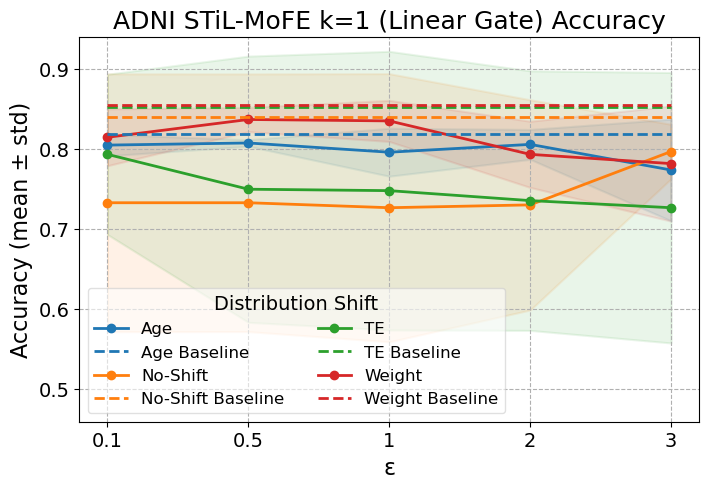

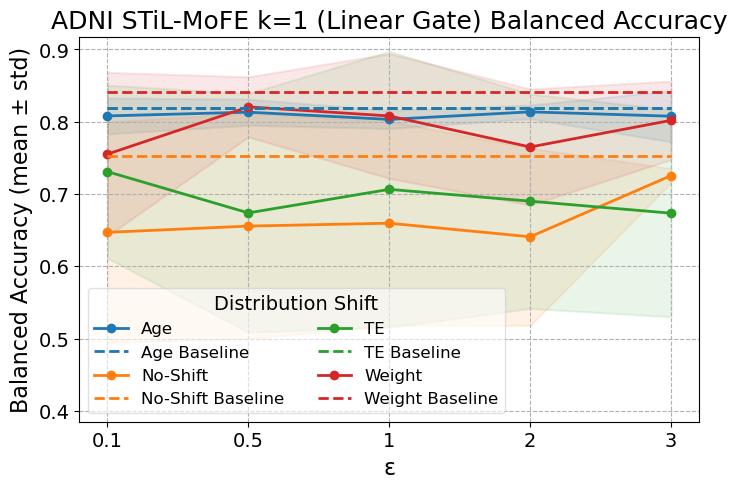

In [1226]:
plot_results(path="final_dataset/MoE1-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.acc", "test.balanced_acc"], title="ADNI STiL-MoFE k=1 (Linear Gate)", just_plot=False)

In [1227]:
#plot_results(path="final_dataset/MoE1-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=1 MLP

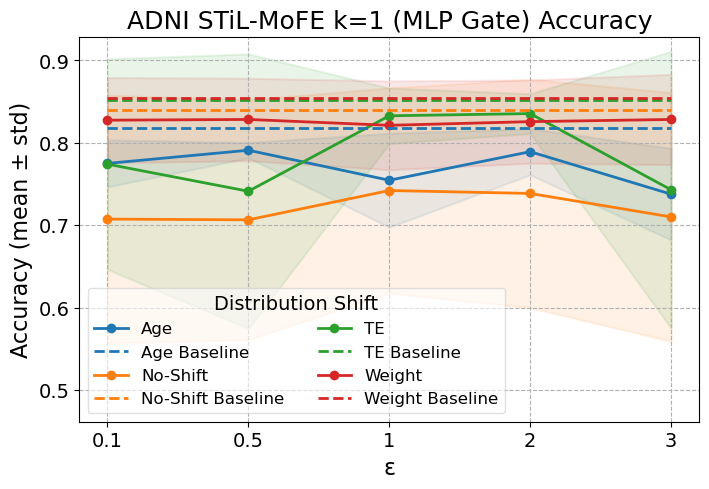

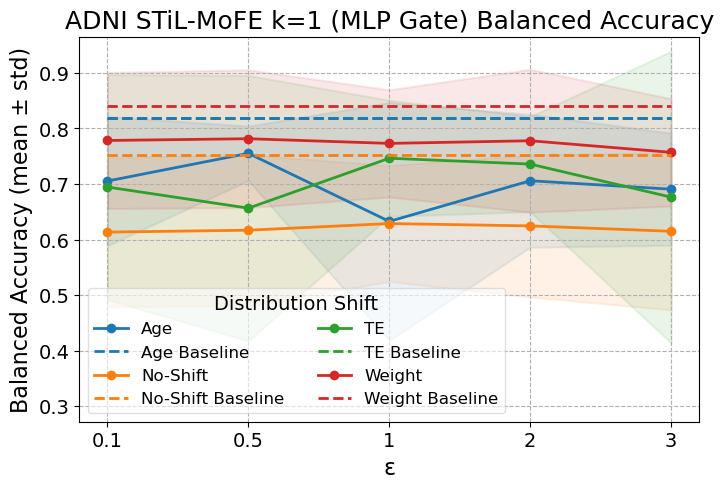

In [1228]:
plot_results(path="final_dataset/MoE1-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.acc", "test.balanced_acc"], title="ADNI STiL-MoFE k=1 (MLP Gate)")

In [1229]:
#plot_results(path="final_dataset/MoE1-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=2 linear

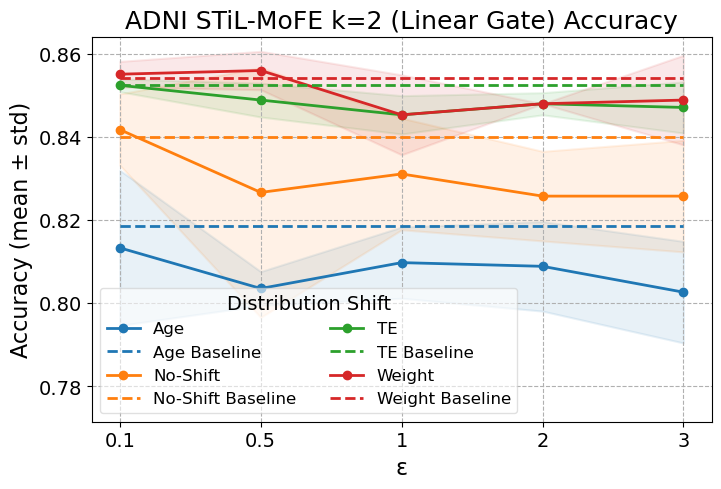

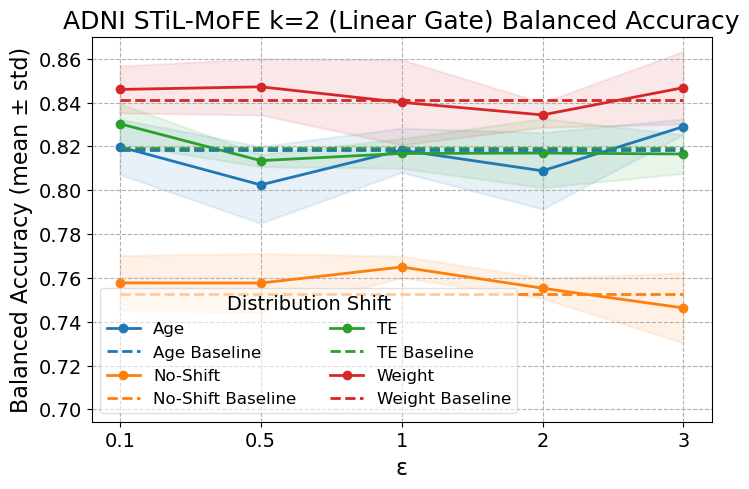

In [1230]:
plot_results(path="final_dataset/MoE2-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.acc", "test.balanced_acc"], title="ADNI STiL-MoFE k=2 (Linear Gate)")

In [1231]:
#plot_results(path="final_dataset/MoE2-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=2 MLP

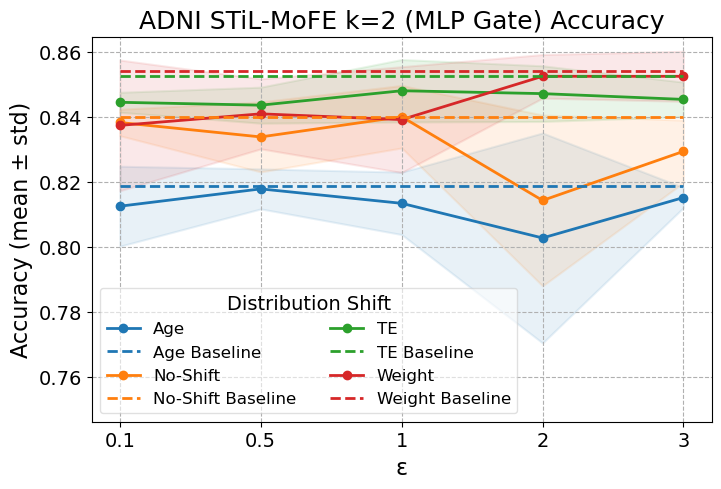

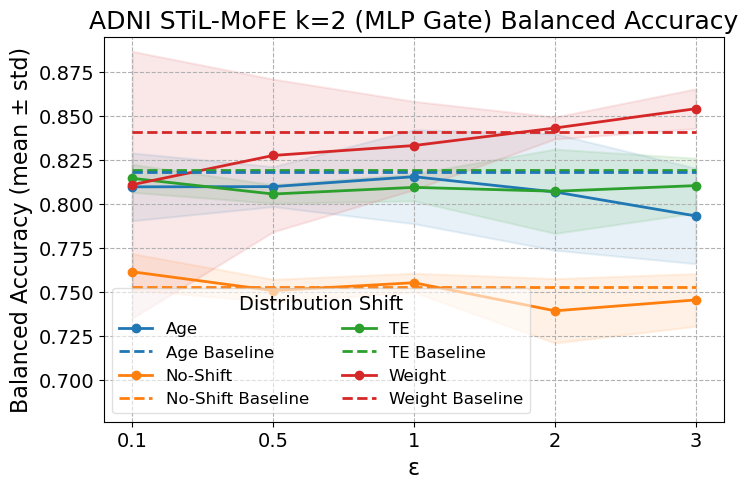

In [1232]:
plot_results(path="final_dataset/MoE2-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.acc", "test.balanced_acc"], title="ADNI STiL-MoFE k=2 (MLP Gate)")

In [1233]:
#plot_results(path="final_dataset/MoE2-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=3 Linear

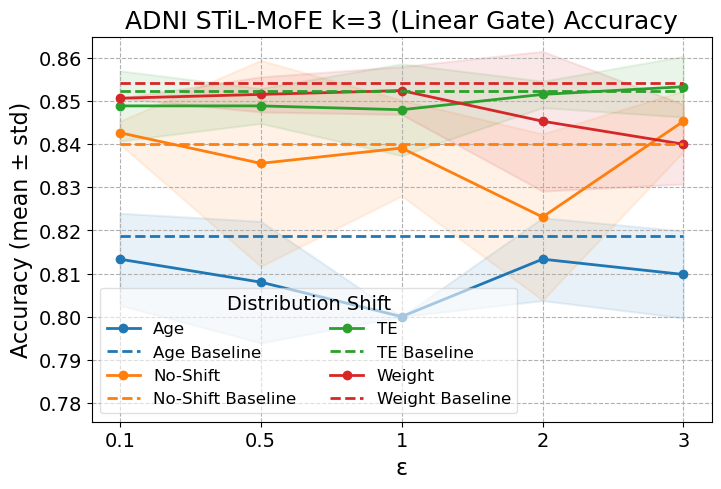

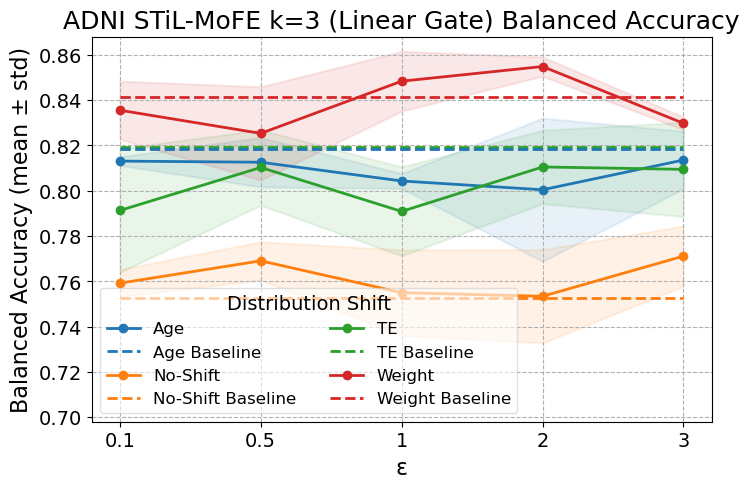

In [1234]:
plot_results(path="final_dataset/MoE3-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.acc", "test.balanced_acc"], title="ADNI STiL-MoFE k=3 (Linear Gate)")

In [1235]:
#plot_results(path="final_dataset/MoE3-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=3 MLP

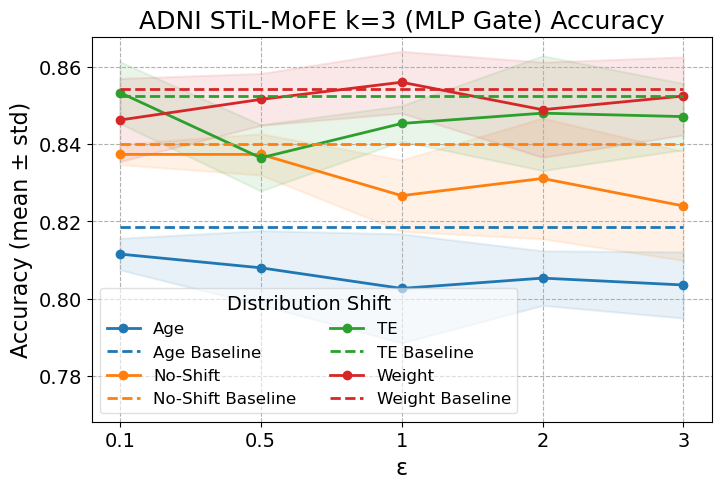

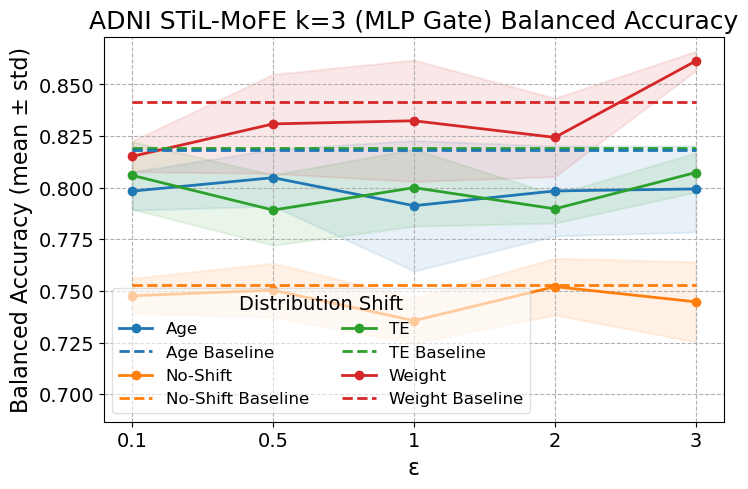

In [1236]:
plot_results(path="final_dataset/MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.acc", "test.balanced_acc"], title="ADNI STiL-MoFE k=3 (MLP Gate)")

In [1237]:
#plot_results(path="final_dataset/MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

### Switch Transformer

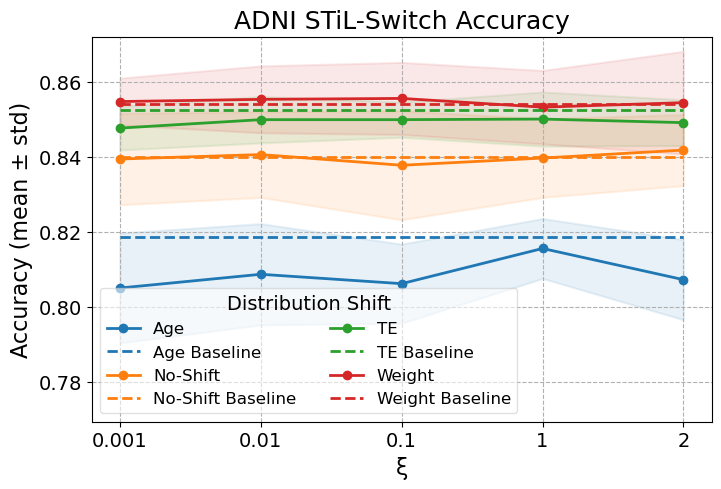

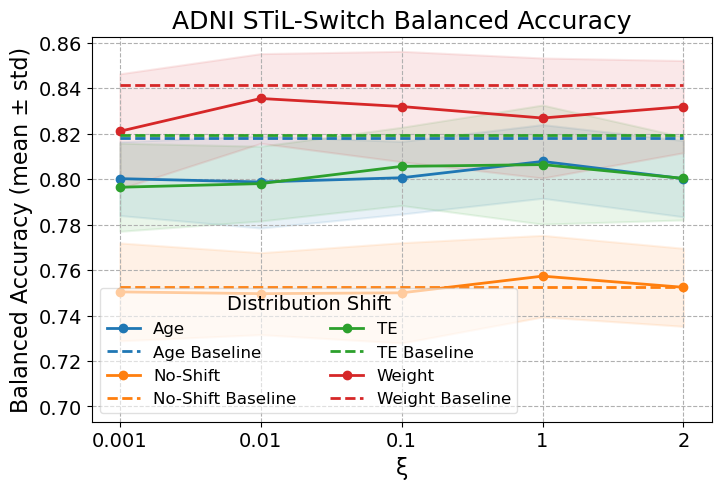

In [1238]:
plot_results(path="final_dataset/MoE1-Switch-NumE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.acc", "test.balanced_acc"], title="ADNI STiL-Switch", pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?(?:\.yaml)?_(?:adni_)?([a-zA-Z]+)_final_seed")

In [1239]:
#plot_results(path="final_dataset/MoE1-Switch-NumE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.expert_no0.entropy", "test.expert_no1.entropy", "test.expert_no2.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

In [1240]:
#plot_results(path="final_dataset/MoE1-Switch-NumE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["MoE.test.x_ai.class_prob_0", "MoE.test.x_ai.class_prob_1", "MoE.test.x_ai.class_prob_2"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## Latent Augmentation, all labeled

In [1241]:
def summarize_please(df: pd.DataFrame, metrics):
    # Helper to convert tensors to floats
    def tensor_to_float(x):
        if isinstance(x, str) and "tensor" in x:
            new_x = x.strip().split("tensor(")[1][:-1]
            new_x = new_x.split(",")[0] if "," in new_x else new_x
            return float(new_x)
        return x

    df = df.copy()

    # Apply conversion
    for col in df.columns:
        df[col] = df[col].apply(tensor_to_float)

    display(df)

    numeric_cols = (
        df.select_dtypes(include="number")
          .columns
          .drop(["Seed"], errors="ignore")
          .intersection(metrics)
    )

    summary_df = (
        df
        .groupby(["Shift", "Classifier", "Method"], as_index=False)
        .agg(
            **{
                f"{col}_mean": (col, "mean")
                for col in numeric_cols
            },
            **{
                f"{col}_std": (col, "std")
                for col in numeric_cols
            },
            Seed=("Seed", list)
        )
    )

    return summary_df

In [1242]:
def reshape_acc_to_csv(df, value_base: str, output_file="reshaped_acc.csv"):
    col_map = {
        "multi": "$f_m$",
        "image": "$f_i$",
        "tabular": "$f_t$",
        "all": "All"
    }

    df = df.copy()
    df["acc_col"] = df["Classifier"].map(col_map)

    mean_col = value_base + "_mean"
    std_col  = value_base + "_std"

    pivot_mean = df.pivot_table(
        index=["Shift", "Method"],
        columns="acc_col",
        values=mean_col
    )

    pivot_std = df.pivot_table(
        index=["Shift", "Method"],
        columns="acc_col",
        values=std_col
    )

    pivot_df = pivot_mean.copy()

    for col in pivot_df.columns:
        pivot_df[col] = (
            (pivot_mean[col] * 100).round(2).astype(str)
            + " ± "
            + (pivot_std[col] * 100).round(2).astype(str)
        )

    pivot_df = pivot_df.reset_index()
    pivot_df.fillna("", inplace=True)

    pivot_df = pivot_df[["Shift","Method","$f_m$","$f_i$","$f_t$","All"]]
    pivot_df.to_csv(output_file, index=False)
    display(pivot_df)

In [1243]:
f_lat_path = os.path.join(BASE_PATH, "final_dataset/latent-augmentation-all-labeled")
df_lat = create_three_group_df(dir_path=f_lat_path, filename="test", one_per_seed=False)
#display(df_lat)
summed_df_lat = summarize_please(df=df_lat, metrics=["test.acc", "test.balanced_acc"])
#display(summed_df_lat[summed_df_lat["Classifier"] == "all"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
#display(summed_df_lat[summed_df_lat["Classifier"] == "image"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
#display(summed_df_lat[summed_df_lat["Classifier"] == "tabular"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
#display(summed_df_lat[summed_df_lat["Classifier"] == "multi"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
reshape_acc_to_csv(df=summed_df_lat[["test.acc_mean", "test.acc_std", "test.balanced_acc_mean", "test.balanced_acc_std", "Shift", "Classifier", "Method"]], output_file="augment_rate_image.csv", value_base="test.acc")

,multimodal.test.classifier.entropy,image.test.classifier.entropy,tabular.test.classifier.entropy,multimodal.test.balanced_acc,image.test.balanced_acc,tabular.test.balanced_acc,test.balanced_acc,test.acc,test.auc,test.acc_multimodal,test.auc_multimodal,test.acc_imaging,test.auc_imaging,test.acc_tabular,test.auc_tabular,Shift,Classifier,Seed,Method
0,0.384200,0.946745,0.467124,0.758012,0.333333,0.768154,0.758012,0.842667,0.916897,0.842667,0.916897,0.493333,0.545817,0.845333,0.922722,normal,tabular,2023,mixstyle
1,0.426106,0.952289,0.463384,0.733818,0.333333,0.723524,0.733818,0.837333,0.905693,0.837333,0.905693,0.493333,0.519355,0.832000,0.909921,normal,all,2024,extrapolation
2,0.421013,1.011597,0.592657,0.819307,0.349085,0.752905,0.819307,0.869333,0.947232,0.869333,0.947232,0.522667,0.606541,0.864000,0.948672,TE,tabular,2022,delta
3,0.552302,1.018289,0.511133,0.801427,0.333333,0.837651,0.801427,0.856000,0.943001,0.856000,0.943001,0.477333,0.511396,0.856000,0.947768,weight,multi,2022,delta
4,0.526986,0.999484,0.653056,0.800772,0.332097,0.743027,0.800772,0.802667,0.914660,0.802667,0.914660,0.658667,0.480993,0.808000,0.909110,age,tabular,2023,delta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,0.437272,0.959249,0.501668,0.761504,0.333333,0.751553,0.761504,0.840000,0.918300,0.840000,0.918300,0.493333,0.551010,0.840000,0.916705,normal,all,2023,extrapolation
701,0.339640,0.945036,0.351945,0.753187,0.333333,0.750678,0.753187,0.840000,0.906866,0.840000,0.906866,0.493333,0.551988,0.845333,0.912607,normal,all,2023,mixstyle
702,0.435820,1.049526,0.531646,0.810982,0.329882,0.837651,0.810982,0.853333,0.951688,0.853333,0.951688,0.469333,0.527714,0.856000,0.950417,weight,all,2024,mixstyle
703,0.475881,1.026747,0.503391,0.834868,0.333333,0.818872,0.834868,0.853333,0.951080,0.853333,0.951080,0.477333,0.496436,0.853333,0.953014,weight,image,2022,delta


acc_col,Shift,Method,$f_m$,$f_i$,$f_t$,All
0,TE,delta,84.91 ± 0.87,85.4 ± 0.99,85.44 ± 1.32,85.27 ± 0.86
1,TE,extrapolation,85.31 ± 1.06,85.56 ± 1.32,84.69 ± 0.72,85.72 ± 0.54
2,TE,mixstyle,85.09 ± 1.02,85.41 ± 0.95,85.55 ± 0.93,85.13 ± 0.91
3,TE,noise,85.2 ± 0.64,85.04 ± 0.7,85.23 ± 0.78,85.49 ± 0.57
4,age,delta,80.72 ± 1.44,81.62 ± 1.08,81.73 ± 0.98,80.64 ± 1.47
5,age,extrapolation,81.36 ± 1.13,82.0 ± 1.04,82.05 ± 0.96,81.62 ± 0.95
6,age,mixstyle,81.92 ± 0.91,81.96 ± 1.1,81.76 ± 0.44,81.7 ± 0.67
7,age,noise,81.63 ± 0.72,81.79 ± 1.12,81.55 ± 1.01,81.87 ± 0.43
8,normal,delta,83.97 ± 0.69,83.87 ± 1.12,84.08 ± 0.55,83.53 ± 0.99
9,normal,extrapolation,84.03 ± 1.04,83.84 ± 1.28,84.35 ± 0.38,83.79 ± 0.79


# DVM

## Baseline

In [1244]:
f_base_path = os.path.join(BASE_DVM_PATH, "baseline")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="test", one_per_seed=False)
#display(df_c_f_base)
summed_f_base_df = summarize_df(df=df_c_f_base, group_col="Shift")
summed_f_base_df[["test.acc", "test.balanced_acc"]]

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

In [1245]:
summed_f_base_df[["test.acc_multimodal"]]

test.acc_multimodal          
                           mean       std
Shift                                    
black                  0.900908  0.011438
color_miles            0.917713  0.005891
miles                  0.915788  0.005058
normal                 0.966533  0.001701

In [1246]:
f_base_path = os.path.join(BASE_DVM_PATH, "baseline")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="eval", one_per_seed=True)
summed_f_base_df_train = summarize_df(df=df_c_f_base, group_col="Shift")

In [1247]:
summed_f_base_df[["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"]]  

multimodal.test.classifier.entropy            \
                                          mean       std   
Shift                                                      
black                                 0.234728  0.013546   
color_miles                           0.181405  0.008888   
miles                                 0.158757  0.014127   
normal                                0.088828  0.007978   

            image.test.classifier.entropy            \
                                     mean       std   
Shift                                                 
black                            1.476063  0.098321   
color_miles                      1.095296  0.082744   
miles                            0.867900  0.122910   
normal                           0.842979  0.043134   

            tabular.test.classifier.entropy            
                                       mean       std  
Shift                                                  
black                              0.428354  0.009174  
color_miles                        0.502617  0.019159  
miles                              0.542806  0.045177  
normal                             0.346115  0.008932

In [1248]:
summed_f_base_df_train[["multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy"]]  

multimodal.classifier.entropy           image.classifier.entropy  \
                                     mean       std                     mean   
Shift                                                                          
black                              0.1199  0.012180                 0.689467   
color_miles                        0.1084  0.006518                 0.663533   
miles                              0.0893  0.019799                 0.567800   
normal                             0.1214  0.008227                 0.705067   

                      tabular.classifier.entropy            
                  std                       mean       std  
Shift                                                       
black        0.074239                   0.913833  0.006561  
color_miles  0.039233                   0.854567  0.011704  
miles        0.082516                   0.853000  0.038617  
normal       0.029318                   0.951967  0.003774

In [1249]:
summed_f_base_df[["multimodal.test.balanced_acc", "image.test.balanced_acc", "tabular.test.balanced_acc", "test.acc_multimodal", "test.acc_imaging", "test.acc_tabular"]]  

multimodal.test.balanced_acc           image.test.balanced_acc  \
                                    mean       std                    mean   
Shift                                                                        
black                           0.884244  0.012234                0.304703   
color_miles                     0.891435  0.006215                0.435148   
miles                           0.901881  0.006620                0.544227   
normal                          0.960397  0.003545                0.621967   

                      tabular.test.balanced_acc           test.acc_multimodal  \
                  std                      mean       std                mean   
Shift                                                                           
black        0.021922                  0.916042  0.004961            0.900908   
color_miles  0.017571                  0.869945  0.012825            0.917713   
miles        0.024413                  0.871859  0.008726            0.915788   
normal       0.014328                  0.940073  0.001121            0.966533   

                      test.acc_imaging           test.acc_tabular            
                  std             mean       std             mean       std  
Shift                                                                        
black        0.011438         0.362780  0.024261         0.927017  0.003834  
color_miles  0.005891         0.512421  0.019140         0.891589  0.009307  
miles        0.005058         0.592795  0.018147         0.882941  0.009248  
normal       0.001701         0.661400  0.010671         0.949667  0.001447

In [1250]:
summed_f_base_df_train[["multimodal.train.balanced_acc", "image.train.balanced_acc", "tabular.train.balanced_acc", "classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc"]]

multimodal.train.balanced_acc           image.train.balanced_acc  \
                                     mean       std                     mean   
Shift                                                                          
black                            0.964967  0.003402                 0.814900   
color_miles                      0.966733  0.002250                 0.817167   
miles                            0.973967  0.005773                 0.847967   
normal                           0.966367  0.002122                 0.815500   

                      tabular.train.balanced_acc            \
                  std                       mean       std   
Shift                                                        
black        0.020623                   0.721967  0.006087   
color_miles  0.012362                   0.738967  0.001595   
miles        0.030453                   0.748300  0.012095   
normal       0.005583                   0.726867  0.002838   

            classifier.multi.acc           classifier.image.acc            \
                            mean       std                 mean       std   
Shift                                                                       
black                   0.968533  0.003602             0.836133  0.018987   
color_miles             0.970767  0.001436             0.845367  0.010740   
miles                   0.976733  0.005405             0.870000  0.025543   
normal                  0.968400  0.001473             0.835567  0.005582   

            classifier.tab.acc            
                          mean       std  
Shift                                     
black                 0.748400  0.005373  
color_miles           0.765233  0.001405  
miles                 0.770067  0.012532  
normal                0.741033  0.001644

In [1251]:
#plot_one_grouped_df(summed_f_base_df, metrics=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Classifier Case Ratio", metric_name="Case Ratio")

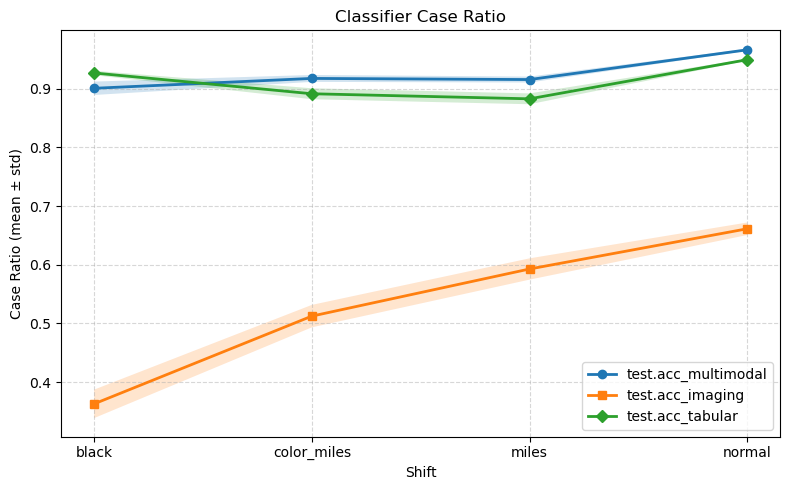

In [1252]:
plot_one_grouped_df(summed_f_base_df, metrics=["test.acc_multimodal", "test.acc_imaging", "test.acc_tabular"], title="Classifier Case Ratio", metric_name="Case Ratio")

## MoE k=3 MLP

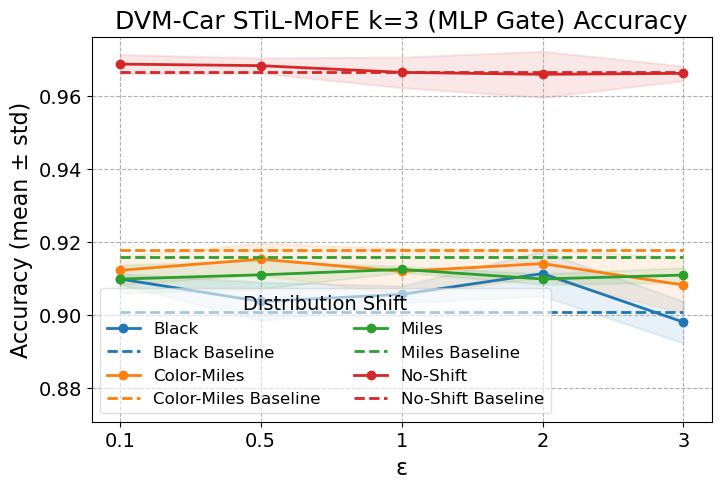

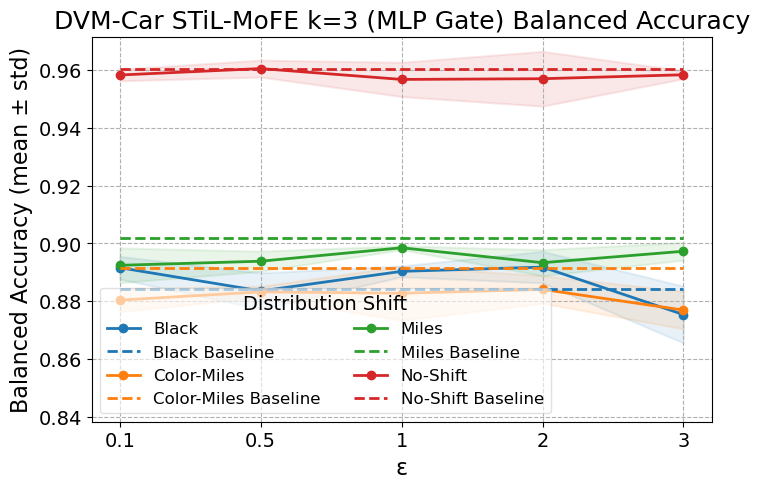

In [1253]:
plot_results(path="MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.acc", "test.balanced_acc"], title="DVM-Car STiL-MoFE k=3 (MLP Gate)", base_path=BASE_DVM_PATH, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

In [1254]:
#plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", base_path=BASE_DVM_PATH, metric=["test.expert_no0.entropy", "test.expert_no1.entropy", "test.expert_no2.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

## MoE k=1 Swift

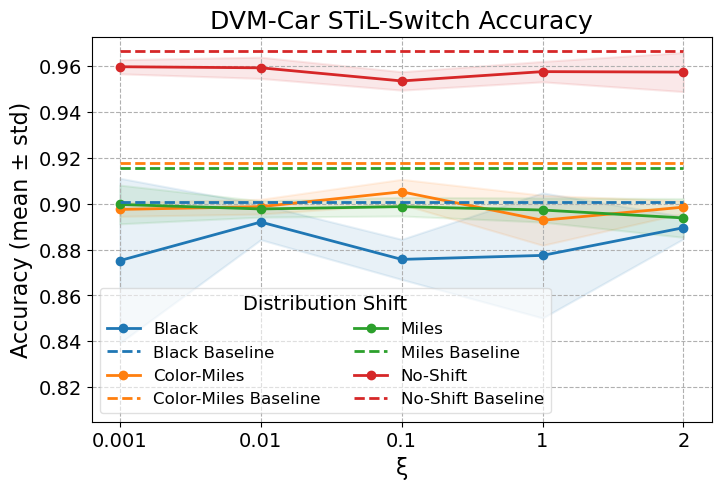

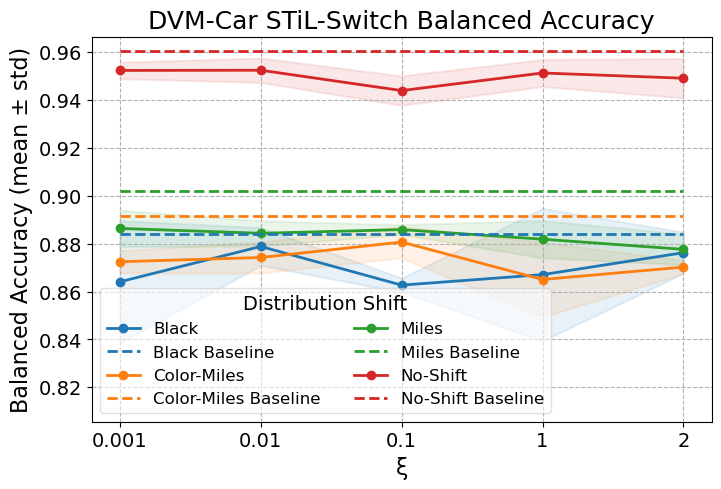

In [1255]:
plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.acc", "test.balanced_acc"], title="DVM-Car STiL-Switch", base_path=BASE_DVM_PATH, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

In [1256]:
#plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", base_path=BASE_DVM_PATH, metric=["test.expert_no0.entropy", "test.expert_no1.entropy", "test.expert_no2.entropy"], title="STiL-Swift", just_plot=True, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

In [1257]:
#plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["MoE.test.x_ai.class_prob_0", "MoE.test.x_ai.class_prob_1", "MoE.test.x_ai.class_prob_2"], title="Mixture of Experts k=1 (linear)", just_plot=True, base_path=BASE_DVM_PATH, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")